# 22.3) K-Means - Base salário idade

In [34]:
# última versão da biblioteca para plotar o gráfico dinâmico.
#!pip install plotly --upgrade

# Machine Learning e Data Science -> Agrupamento

In [35]:
# importar as bibliotecas
import plotly.express as px
# concatenar os dados
import plotly.graph_objects as go
import numpy as np
# padronização dos dados, por conta do algoritmo do agrupamento
# k means é com base na distância, e tem que colocar todos na mesma escala
from sklearn.preprocessing import StandardScaler

# K-means

## Base idade e salário


In [36]:
#Base da idade x e do salário y

x=[20,  27,  21,  37,  46, 53, 55,  47,  52,  32,  39,  41,  39,  48,  48]
y=[1000,1200,2900,1850,900,950,2000,2100,3000,5900,4100,5100,7000,5000,6500]

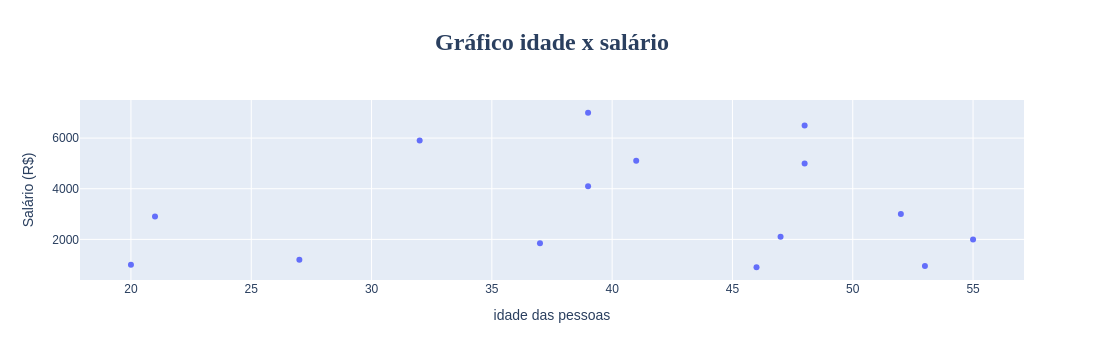

In [37]:
#grafico = px.scatter(x = x, y = y)
grafico = px.scatter(x=x, y=y, title='<b>Gráfico idade x salário</b>') # formato html bold

# Atualiza o layout para renomear os rótulos dos eixos X e Y
grafico.update_layout(
    xaxis_title_text='idade das pessoas',
    yaxis_title_text='Salário (R$)',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico.show()
grafico.write_html("figuras/18-4_grafico.html")
#https://plotly.com/python/interactive-html-export/

In [38]:
from sklearn.cluster import KMeans

In [39]:
# juntar idade e salário no array
base_salario = np.array([[20,1000],[27,1200],[21,2900],[37,1850],[46,900],
                        [53,950],[55,2000],[47,2100],[52,3000],[32,5900],
                        [39,4100],[41,5100],[39,7000],[48,5000],[48,6500]])

In [40]:
# formato de matriz, com dois colchetes 

In [41]:
base_salario

array([[  20, 1000],
       [  27, 1200],
       [  21, 2900],
       [  37, 1850],
       [  46,  900],
       [  53,  950],
       [  55, 2000],
       [  47, 2100],
       [  52, 3000],
       [  32, 5900],
       [  39, 4100],
       [  41, 5100],
       [  39, 7000],
       [  48, 5000],
       [  48, 6500]])

In [42]:
# padronizar os dados , para deixar as variáveis x e y na mesma escala, 1 é dois números e outro é 4 números (que é maio).
scaler_salario = StandardScaler()
base_salario = scaler_salario.fit_transform(base_salario)
base_salario

array([[-1.87963884, -1.11413572],
       [-1.23255006, -1.01725435],
       [-1.78719758, -0.19376273],
       [-0.30813751, -0.70238991],
       [ 0.52383377, -1.1625764 ],
       [ 1.17092255, -1.13835606],
       [ 1.35580506, -0.62972888],
       [ 0.61627503, -0.5812882 ],
       [ 1.0784813 , -0.14532205],
       [-0.77034379,  1.25945777],
       [-0.12325501,  0.38752547],
       [ 0.0616275 ,  0.8719323 ],
       [-0.12325501,  1.79230528],
       [ 0.70871628,  0.82349162],
       [ 0.70871628,  1.55010187]])

In [43]:
len(base_salario) # quantidade de registros

15

In [44]:
import math
# Use a função sqrt() da biblioteca math
resultado_num_cluster = math.sqrt(len(base_salario)/2)
print(resultado_num_cluster)

2.7386127875258306


In [45]:
kmeans_salario = KMeans(n_clusters=3) # quantidade de cluster utilizado para o kmeans salário
# geração dos centroides aleatórios, até a geração final dos 3 clusters ou grupos
kmeans_salario.fit(base_salario)

KMeans(n_clusters=3)

In [46]:
#'init': 'k-means++', otimização para inicializar os clusters iniciais.


In [47]:
kmeans_salario.get_params() 

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

centroide, média dos registros que compõem aquele cluster. Porém, neste caso são dados escalonados, idade e salário.

In [48]:
# observar os centroides dos grupos
centroides = kmeans_salario.cluster_centers_
centroides # criaçã de 3 centroides

array([[ 0.73953003, -0.72661025],
       [ 0.07703438,  1.11413572],
       [-1.63312883, -0.77505093]])

Voltar aos dados reais, com o processo inverso. 

In [51]:
scaler_salario.inverse_transform(kmeans_salario.cluster_centers_) # 3 grupos, média dos registros que fazem parte dos registros.

array([[  48.33333333, 1800.        ],
       [  41.16666667, 5600.        ],
       [  22.66666667, 1700.        ]])

exemplo dos centroides

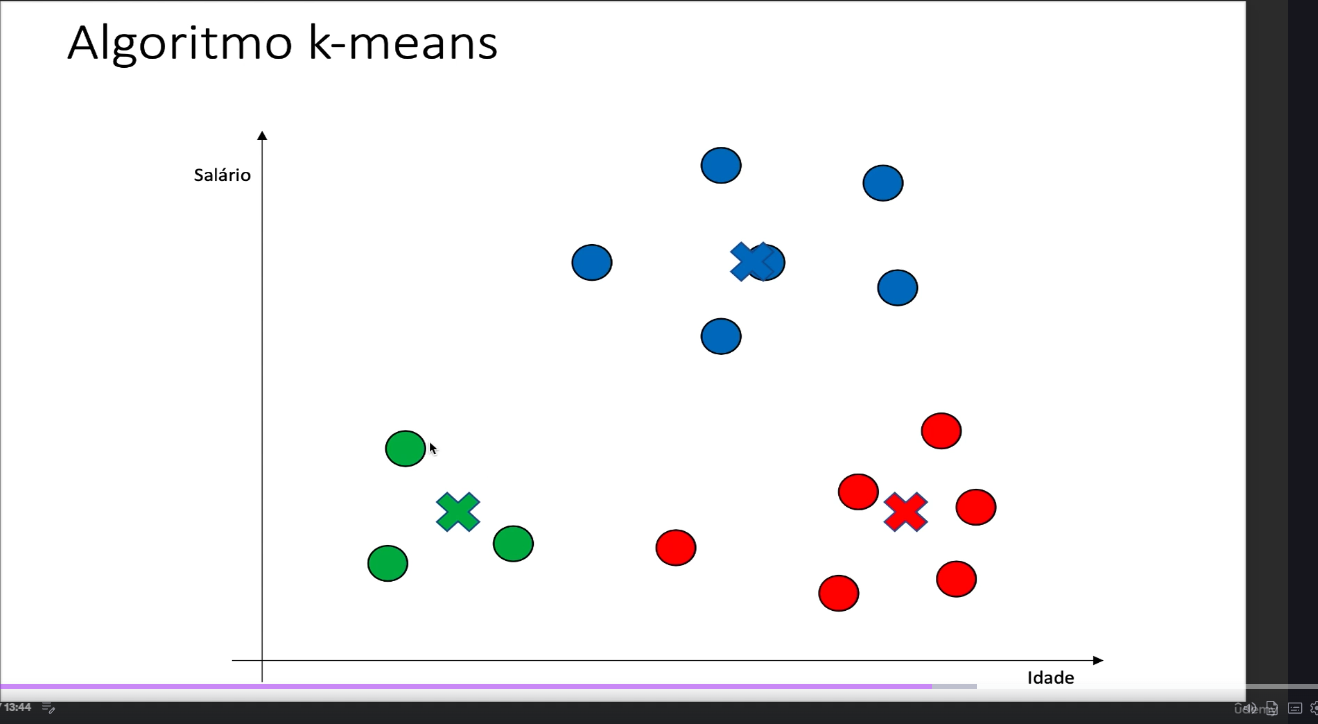

In [52]:
# rotulos indicando onde cada registro pertence

In [53]:
rotulos = kmeans_salario.labels_
rotulos

array([2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int32)

In [55]:
scaler_salario.inverse_transform(kmeans_salario.cluster_centers_)
# 0,1,2 grupos

array([[  48.33333333, 1800.        ],
       [  41.16666667, 5600.        ],
       [  22.66666667, 1700.        ]])

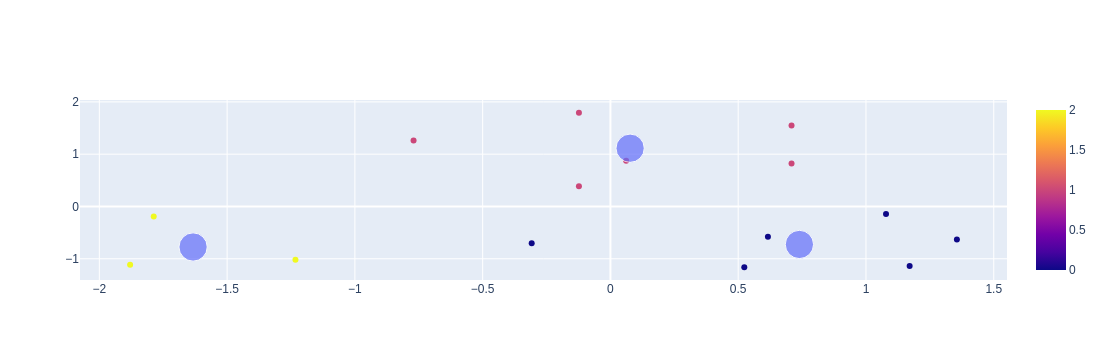

In [57]:
grafico1 = px.scatter(x = base_salario[:,0], y = base_salario[:,1], color=rotulos)
grafico2 = px.scatter(x = centroides[:,0], y = centroides[:,1], size = [12, 12, 12])
grafico3 = go.Figure(data = grafico1.data + grafico2.data)
grafico3.show()

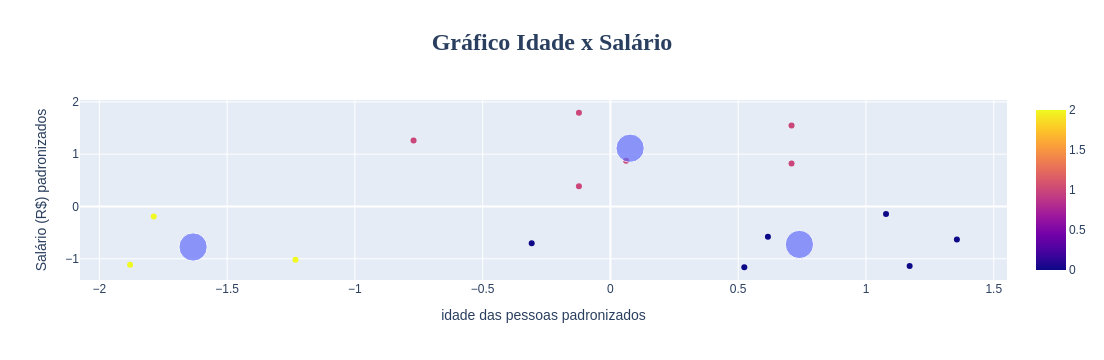

In [62]:
# x base idade e base salário
grafico1 = px.scatter(x = base_salario[:,0], y = base_salario[:,1],color=rotulos)
grafico2 = px.scatter(x = centroides[:,0], y = centroides[:,1], size = [12, 12, 12])
grafico3 = go.Figure(data = grafico1.data + grafico2.data)

# Atualiza o layout para renomear os rótulos dos eixos X e Y
grafico3.update_layout(
    # Defina o título aqui, no gráfico que será exibido
    title_text='<b>Gráfico Idade x Salário</b>',
    xaxis_title_text='idade das pessoas padronizados',
    yaxis_title_text='Salário (R$) padronizados',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)

grafico3.show()
grafico3.write_html("figuras/18-4_grafico2.html")
#https://plotly.com/python/interactive-html-export/

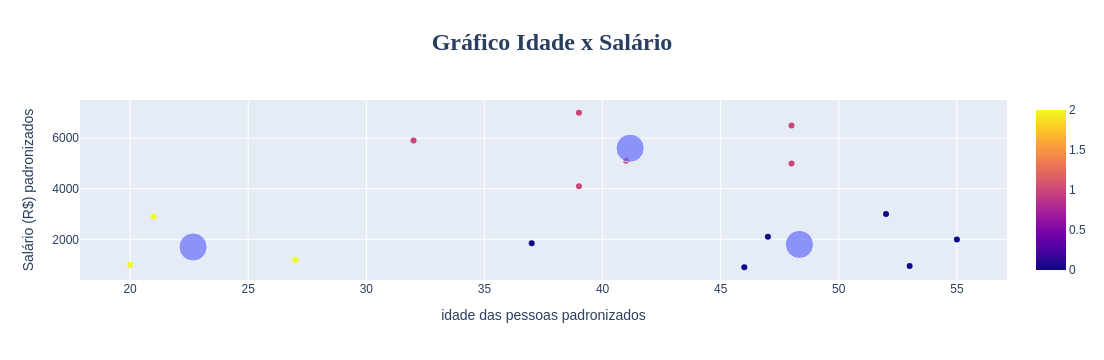

In [66]:
# x base idade e base salário
grafico1 = px.scatter(x = scaler_salario.inverse_transform(base_salario)[:,0], y = scaler_salario.inverse_transform(base_salario)[:,1],color=rotulos)
grafico2 = px.scatter(x = scaler_salario.inverse_transform(kmeans_salario.cluster_centers_)[:,0], y = scaler_salario.inverse_transform(kmeans_salario.cluster_centers_)[:,1], size = [12, 12, 12])
grafico3 = go.Figure(data = grafico1.data + grafico2.data)

# Atualiza o layout para renomear os rótulos dos eixos X e Y
grafico3.update_layout(
    # Defina o título aqui, no gráfico que será exibido
    title_text='<b>Gráfico Idade x Salário</b>',
    xaxis_title_text='idade das pessoas padronizados',
    yaxis_title_text='Salário (R$) padronizados',
    # padrão o título
    title_font_size=24,  # Define o tamanho da fonte do título
    title_font_family='Arial Black', # Uma fonte mais grossa
    title_x=0.5 # Centraliza o título no gráfico
)
grafico3.show()
grafico3.write_html("figuras/18-4_grafico2_2.html")

In [67]:
# centroide posicionado no meio do grupo, média em análise